# Price Prediction - Random Forest

Let's start by importing necessary packages.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

Now read in the dataframe and prepare it for use with `RandomForest`.

In [3]:
df = pd.read_parquet("../all_car_details_cleaned.parquet")

In [4]:
columns_to_drop = [
    "url",
    "num_images",
    "general_inspection",
    "emission_class",
    "comfort_and_convenience",
    "safety_and_security",
    "entertainment_and_media",
    "extras",
    "paint",
]

df.drop(columns=columns_to_drop, errors="ignore", inplace=True)

## Prepare for RF

Split Train and Test.

In [5]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

X_train shape: (374518, 25), X_test shape: (93630, 25)
y_train shape: (374518,), y_test shape: (93630,)


Group rare categories before running OHE.

In [6]:
# We'll do this after grouping for high cardinality features
high_card_features = ['make', 'car_title'] # Features to apply grouping
# Other categorical features that don't need grouping but need OHE
# Exclude high_card_features as they will be handled, and ensure no numeric features are accidentally included
other_categorical_features = [col for col in X_train.select_dtypes(include=['object', 'category']).columns if col not in high_card_features]
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()

print(f"High cardinality features to group: {high_card_features}")
print(f"Other categorical features for OHE: {other_categorical_features}")
print(f"Numerical features: {numerical_features}")

High cardinality features to group: ['make', 'car_title']
Other categorical features for OHE: ['seller', 'location', 'body_type', 'used_type', 'drivetrain', 'seats', 'doors', 'full_service_history', 'gearbox', 'gears', 'cylinders', 'fuel_type', 'exterior_colour', 'upholstery_colour', 'upholstery']
Numerical features: ['mileage', 'previous_owner', 'power', 'engine_size', 'empty_weight', 'fuel_consumption', 'co2_emissions', 'age_months']


In [7]:
def get_rare_categories(series, threshold_percentage):
    value_counts_normalized = series.value_counts(normalize=True)
    return value_counts_normalized[value_counts_normalized < threshold_percentage].index

make_threshold_percentage = 0.0001
title_threshold_percentage = 0.00005

# Create copies to avoid SettingWithCopyWarning
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

for feature, threshold in zip(['make', 'car_title'], [make_threshold_percentage, title_threshold_percentage]):
    if feature in X_train_processed.columns:
        print(f"\nProcessing feature: {feature}")
        print(f"Unique values in X_train before grouping: {X_train_processed[feature].nunique()}")
        
        # Learn rare categories from X_train
        rare_categories_train = get_rare_categories(X_train_processed[feature], threshold)
        
        # Apply to X_train
        X_train_processed[feature] = X_train_processed[feature].apply(lambda x: f'Other_{feature}' if x in rare_categories_train else x)
        print(f"Unique values in X_train after grouping: {X_train_processed[feature].nunique()}")
        
        # Apply to X_test (using rare categories learned from X_train)
        if feature in X_test_processed.columns:
            X_test_processed[feature] = X_test_processed[feature].apply(lambda x: f'Other_{feature}' if x in rare_categories_train else x)
            # Handle new categories in X_test not seen in X_train's common categories
            # by mapping them to 'Other_feature' as well
            common_categories_train = X_train_processed[feature].unique()
            X_test_processed[feature] = X_test_processed[feature].apply(lambda x: f'Other_{feature}' if x not in common_categories_train else x)
            print(f"Unique values in X_test after grouping: {X_test_processed[feature].nunique()}")
    else:
        print(f"Feature {feature} not found in X_train.")

# Update the list of categorical features for OHE to include the now-grouped high-cardinality ones
all_categorical_features_for_ohe = high_card_features + other_categorical_features

total_ohe_cols_estimate = 0
print("\n--- Estimating OHE columns ---")
for col in all_categorical_features_for_ohe:
    if col in X_train_processed.columns:
        unique_vals = X_train_processed[col].nunique()
        print(f"Feature '{col}': {unique_vals} unique values (after grouping/filling NaNs)")
        total_ohe_cols_estimate += unique_vals
    else:
        print(f"Feature '{col}' not found in X_train_processed for OHE estimation.")
print(f"Estimated total columns from OHE (if drop=None): {total_ohe_cols_estimate}")
print(f"Numerical features to be passed through: {len(numerical_features)}")
print(f"Grand total estimated features: {total_ohe_cols_estimate + len(numerical_features)}")


Processing feature: make
Unique values in X_train before grouping: 220
Unique values in X_train after grouping: 109
Unique values in X_test after grouping: 109

Processing feature: car_title
Unique values in X_train before grouping: 2756
Unique values in X_train after grouping: 1362
Unique values in X_test after grouping: 1360

--- Estimating OHE columns ---
Feature 'make': 109 unique values (after grouping/filling NaNs)
Feature 'car_title': 1362 unique values (after grouping/filling NaNs)
Feature 'seller': 3 unique values (after grouping/filling NaNs)
Feature 'location': 9 unique values (after grouping/filling NaNs)
Feature 'body_type': 28 unique values (after grouping/filling NaNs)
Feature 'used_type': 6 unique values (after grouping/filling NaNs)
Feature 'drivetrain': 3 unique values (after grouping/filling NaNs)
Feature 'seats': 28 unique values (after grouping/filling NaNs)
Feature 'doors': 10 unique values (after grouping/filling NaNs)
Feature 'full_service_history': 2 unique va

One-Hot Encode categorical features and fill NAs.

In [8]:
print("Filling NaNs in categorical features with 'Missing_Cat_Value'...")
for col in all_categorical_features_for_ohe:
    if col in X_train_processed.columns:
        X_train_processed[col] = X_train_processed[col].fillna('Missing_Cat_Value')
    if col in X_test_processed.columns:
        X_test_processed[col] = X_test_processed[col].fillna('Missing_Cat_Value')
print("NaNs filled in categorical features.")

preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True, drop=None), all_categorical_features_for_ohe)
    ],
    remainder='passthrough'
)
print("Preprocessor created.")

X_train_final = preprocessor.fit_transform(X_train_processed)
print(f"Shape of sparse X_train_final: {X_train_final.shape}")
X_test_final = preprocessor.transform(X_test_processed)
print(f"Shape of sparse X_test_final: {X_test_final.shape}")

# Get feature names (important for Random Forest feature importance later)
ohe_feature_names = preprocessor.named_transformers_['ohe'].get_feature_names_out(all_categorical_features_for_ohe)
# original_cols should be X_train_processed.columns
passthrough_feature_names = [col for col in X_train_processed.columns if col not in all_categorical_features_for_ohe and col in numerical_features]
final_feature_names = list(ohe_feature_names) + passthrough_feature_names
print(f"Number of features after OHE: {len(final_feature_names)}")

Filling NaNs in categorical features with 'Missing_Cat_Value'...
NaNs filled in categorical features.
Preprocessor created.
Shape of sparse X_train_final: (374518, 1685)
Shape of sparse X_test_final: (93630, 1685)
Number of features after OHE: 1685


Impute features with their means, for price based on the mean of the brand.

In [9]:
# Identify numerical features that were passed through the ColumnTransformer
# These are the columns in X_train_final_df / X_test_final_df that were originally numerical
# and might need imputation if they had NaNs.
numerical_cols_to_impute = [
    col for col in final_feature_names if col in numerical_features
]

# Convert X_train_final and X_test_final (outputs of ColumnTransformer) to DataFrames.
# It's crucial to align their indices with X_train_processed and X_test_processed
# (inputs to ColumnTransformer) to correctly map the 'make' for imputation.
X_train_final_df = pd.DataFrame(
    X_train_final.toarray() if hasattr(X_train_final, "toarray") else X_train_final,
    columns=final_feature_names,
    index=X_train_processed.index,  # Align index with pre-OHE data
)
X_test_final_df = pd.DataFrame(
    X_test_final.toarray() if hasattr(X_test_final, "toarray") else X_test_final,
    columns=final_feature_names,
    index=X_test_processed.index,  # Align index with pre-OHE data
)

print(
    f"Numerical columns to impute in the final (post-OHE) data: {numerical_cols_to_impute}"
)

# Impute numerical features using make-specific means from the training data
for col_name in numerical_cols_to_impute:
    print(f"Imputing column: {col_name} using make-specific means")

    # 1. Calculate make-specific means for the current numerical column 'col_name'
    #    USING ONLY TRAINING DATA (X_train_processed) to prevent data leakage.
    #    X_train_processed contains the original 'make' column and 'col_name'.
    make_specific_col_means = X_train_processed.groupby("make")[col_name].mean()

    # 2. Calculate the overall mean for 'col_name' from TRAINING DATA as a fallback.
    overall_col_mean = X_train_processed[col_name].mean()

    # --- Impute X_train_final_df ---
    # Get the 'make' series from X_train_processed, aligned by index with X_train_final_df.
    # This ensures we use the correct 'make' for each row in X_train_final_df.
    train_makes = X_train_processed.loc[X_train_final_df.index, "make"]

    # Create a series of imputation values by mapping each row's 'make' to its specific mean for 'col_name'.
    imputation_values_train = train_makes.map(make_specific_col_means)

    # Apply these mapped means to fill NaNs in the current column 'col_name' of X_train_final_df.
    # Series.fillna(Series) aligns on index, so this works as X_train_final_df[col_name] and imputation_values_train share an index.
    X_train_final_df[col_name] = X_train_final_df[col_name].fillna(
        imputation_values_train
    )

    # For any NaNs still remaining (e.g., a 'make' in train_makes was not in make_specific_col_means
    # or make_specific_col_means itself had NaNs for that make), fill with the overall column mean.
    X_train_final_df[col_name] = X_train_final_df[col_name].fillna(overall_col_mean)

    # --- Impute X_test_final_df ---
    # Get the 'make' series from X_test_processed, aligned by index with X_test_final_df.
    test_makes = X_test_processed.loc[X_test_final_df.index, "make"]

    # Create a series of imputation values by mapping each row's 'make' to its specific mean for 'col_name'
    # (using make_specific_col_means LEARNED FROM TRAINING DATA).
    imputation_values_test = test_makes.map(make_specific_col_means)

    # Apply these mapped means to fill NaNs in the current column 'col_name' of X_test_final_df.
    X_test_final_df[col_name] = X_test_final_df[col_name].fillna(imputation_values_test)

    # For any NaNs still remaining (e.g., a 'make' in test_makes was not in make_specific_col_means,
    # or new makes in test set), fill with the overall column mean (LEARNED FROM TRAINING DATA).
    X_test_final_df[col_name] = X_test_final_df[col_name].fillna(overall_col_mean)


# Convert back to numpy arrays for the model
X_train_final = X_train_final_df.values
X_test_final = X_test_final_df.values

print(
    "Missing values in numerical columns imputed based on 'make'-specific and overall column means from training data."
)

Numerical columns to impute in the final (post-OHE) data: ['mileage', 'previous_owner', 'power', 'engine_size', 'empty_weight', 'fuel_consumption', 'co2_emissions', 'age_months']
Imputing column: mileage using make-specific means
Imputing column: previous_owner using make-specific means
Imputing column: power using make-specific means
Imputing column: engine_size using make-specific means
Imputing column: empty_weight using make-specific means
Imputing column: fuel_consumption using make-specific means
Imputing column: co2_emissions using make-specific means
Imputing column: age_months using make-specific means
Missing values in numerical columns imputed based on 'make'-specific and overall column means from training data.


## Training Baseline Model

In [16]:
print("--- Training Random Forest Model ---")

rf_model = RandomForestRegressor(
    n_estimators=100,       # Start with a reasonable number, e.g., 100-300
    max_depth=None,         # Let trees grow deep initially, can be tuned
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,              # Use all available cores
    oob_score=True          # Optional: Use out-of-bag samples to estimate generalization error
)

# Random Forest fits directly on the (sparse) feature matrix and target vector
rf_model.fit(X_train_final, y_train)

print("Random Forest model training complete.")
if rf_model.oob_score:
    print(f"Out-of-Bag R^2 score: {rf_model.oob_score_:.4f}")

--- Training Random Forest Model ---
Random Forest model training complete.
Out-of-Bag R^2 score: 0.7818


In [12]:
print("--- Evaluating Random Forest Model ---")
y_pred_train_rf = rf_model.predict(X_train_final)
y_pred_test_rf = rf_model.predict(X_test_final)

# Training set metrics
mae_train_rf = mean_absolute_error(y_train, y_pred_train_rf)
r2_train_rf = r2_score(y_train, y_pred_train_rf)
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_pred_train_rf))

# Test set metrics
mae_test_rf = mean_absolute_error(y_test, y_pred_test_rf)
r2_test_rf = r2_score(y_test, y_pred_test_rf)
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))

print(f"Random Forest - Training Set Performance:")
print(f"  Mean Absolute Error (MAE): {mae_train_rf:.4f}")
print(f"  R-squared (R2): {r2_train_rf:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_train_rf:.4f}")

print(f"\nRandom Forest - Test Set Performance:")
print(f"  Mean Absolute Error (MAE): {mae_test_rf:.4f}")
print(f"  R-squared (R2): {r2_test_rf:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_test_rf:.4f}")


--- Evaluating Random Forest Model ---
Random Forest - Training Set Performance:
  Mean Absolute Error (MAE): 11015.2841
  R-squared (R2): 0.9698
  Root Mean Squared Error (RMSE): 27337.7915

Random Forest - Test Set Performance:
  Mean Absolute Error (MAE): 29822.8709
  R-squared (R2): 0.7823
  Root Mean Squared Error (RMSE): 73268.3398



--- Feature Importance (Random Forest Model) ---
Top 20 features by importance (Random Forest):
                           feature  importance
1684                    age_months    0.261853
1682              fuel_consumption    0.137858
1679                         power    0.110565
1681                  empty_weight    0.052558
1677                       mileage    0.044911
1680                   engine_size    0.026977
57                 make_land-rover    0.020866
1683                 co2_emissions    0.018903
1672  upholstery_Missing_Cat_Value    0.015879
44                    make_hyundai    0.014464
101                    make_toyota    0.012606
1478                   location_DE    0.012314
1678                previous_owner    0.009541
1474         seller_Private seller    0.008675
50                     make_jaguar    0.008016
8                        make_audi    0.007735
68              make_mercedes-benz    0.007243
29                      make_dodge    0.006156
1483      

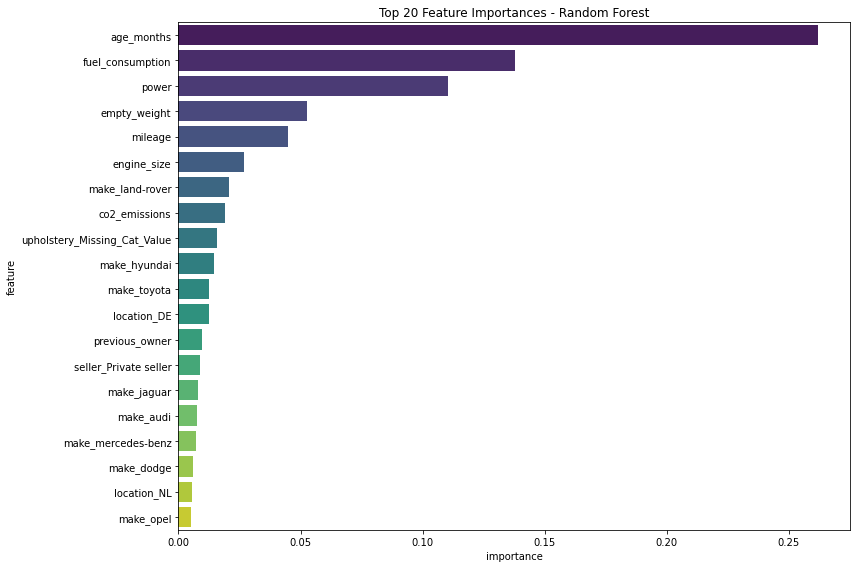

In [13]:
print("\n--- Feature Importance (Random Forest Model) ---")
importances_rf = rf_model.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df_rf = pd.DataFrame({
    'feature': final_feature_names, # Use the names from preprocessor
    'importance': importances_rf
})

# Sort by importance
feature_importance_df_rf = feature_importance_df_rf.sort_values(by='importance', ascending=False)

print("Top 20 features by importance (Random Forest):")
print(feature_importance_df_rf.head(20))

# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df_rf.head(20), palette='viridis')
plt.title('Top 20 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

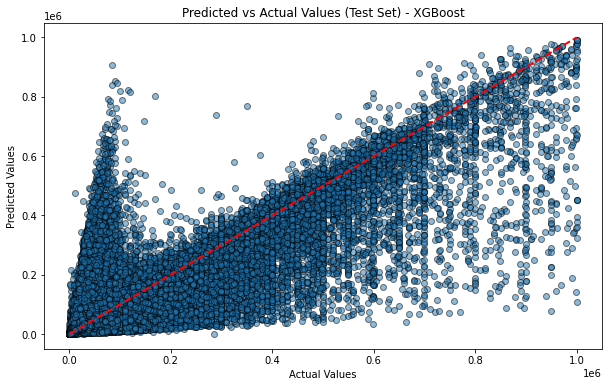

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test_rf, alpha=0.5, edgecolors="k")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Diagonal line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual Values (Test Set) - XGBoost")
plt.show()

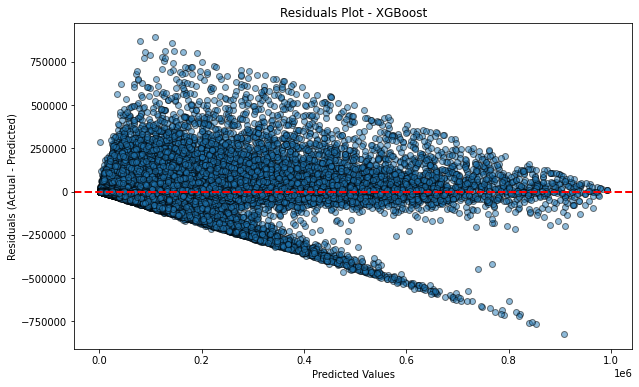

In [18]:
residuals = y_test - y_pred_test_rf

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test_rf, residuals, alpha=0.5, edgecolors="k")
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals Plot - XGBoost")
plt.show()

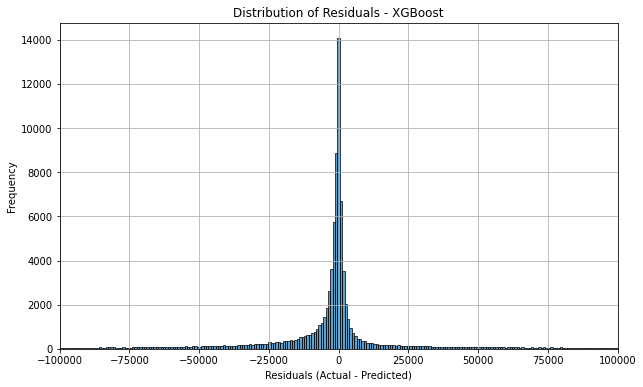

In [19]:
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=2000, edgecolor='k', alpha=0.7)
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals - XGBoost')
plt.grid(True)
plt.xlim(-100000, 100000)
plt.show()

This all looks very promising, let's now try some hyperparameter tuning to see if we can get more performance out of it.

## Hyperparameter Tuning

In [14]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': randint(100, 500),  # Number of trees in random forest
    'max_features': ['sqrt', 'log2', 0.5, 0.7], # Number of features to consider at every split
    'max_depth': [None] + list(randint(10, 30).rvs(5)), # Maximum number of levels in tree + None
    'min_samples_split': randint(2, 50),    # Minimum number of samples required to split a node
    'min_samples_leaf': randint(1, 20),     # Minimum number of samples required at each leaf node
    'bootstrap': [True] # Method of selecting samples for training each tree (True is default and usually best)
}

# Initialize the RandomForestRegressor
rf_tuning = RandomForestRegressor(random_state=42, n_jobs=-1, oob_score=False) # oob_score can slow down CV

# Initialize RandomizedSearchCV
# n_iter controls the number of different combinations to try
# cv is the number of cross-validation folds
# Use a score that can be maximized (hence negative MAE or MSE, or R2 directly)
rf_random_search = RandomizedSearchCV(
    estimator=rf_tuning,
    param_distributions=param_dist,
    n_iter=15,  # Adjust based on available time, 25-50 is a good start
    cv=2,       # 2-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=1,  # Use all available cores for CV too
    scoring='neg_mean_absolute_error' # Or 'neg_mean_absolute_error'
)

print("--- Starting RandomizedSearchCV for Random Forest ---")
# Fit RandomizedSearchCV
# Note: rf_random_search.fit expects X_train_final to be a dense array or compatible sparse format.
# If X_train_final is a sparse matrix from ColumnTransformer, it should work.
# If it's a DataFrame that became sparse, ensure it's handled correctly.
rf_random_search.fit(X_train_final, y_train)

print("RandomizedSearchCV complete.")
print("Best parameters found: ", rf_random_search.best_params_)
print("Best R2 score found: ", rf_random_search.best_score_)

# Get the best model
best_rf_model = rf_random_search.best_estimator_

# Evaluate the best model on the test set
y_pred_train_best_rf = best_rf_model.predict(X_train_final)
y_pred_test_best_rf = best_rf_model.predict(X_test_final)

# Training set metrics
mae_train_best_rf = mean_absolute_error(y_train, y_pred_train_best_rf)
r2_train_best_rf = r2_score(y_train, y_pred_train_best_rf)
mse_train_best_rf = mean_squared_error(y_train, y_pred_train_best_rf)

# Test set metrics
mae_test_best_rf = mean_absolute_error(y_test, y_pred_test_best_rf)
r2_test_best_rf = r2_score(y_test, y_pred_test_best_rf)
mse_test_best_rf = mean_squared_error(y_test, y_pred_test_best_rf)

print("\\n--- Performance of Best Random Forest Model (from RandomizedSearchCV) ---")
print(f"Training Metrics: MAE: {mae_train_best_rf:.4f}, MSE: {mse_train_best_rf:.4f}, R²: {r2_train_best_rf:.4f}")
print(f"Test Metrics: MAE: {mae_test_best_rf:.4f}, MSE: {mse_test_best_rf:.4f}, R²: {r2_test_best_rf:.4f}")

if hasattr(best_rf_model, 'oob_score_') and best_rf_model.oob_score_: # If best model was fit with oob_score=True
    print(f"Best model OOB R^2 score: {best_rf_model.oob_score_:.4f}")


--- Starting RandomizedSearchCV for Random Forest ---
Fitting 2 folds for each of 15 candidates, totalling 30 fits
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=15, min_samples_split=44, n_estimators=171; total time=  49.7s
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=15, min_samples_split=44, n_estimators=171; total time=  46.1s
[CV] END bootstrap=True, max_depth=12, max_features=sqrt, min_samples_leaf=7, min_samples_split=20, n_estimators=314; total time= 1.4min
[CV] END bootstrap=True, max_depth=12, max_features=sqrt, min_samples_leaf=7, min_samples_split=20, n_estimators=314; total time= 1.4min
[CV] END bootstrap=True, max_depth=17, max_features=0.5, min_samples_leaf=4, min_samples_split=41, n_estimators=251; total time=12.5min
[CV] END bootstrap=True, max_depth=17, max_features=0.5, min_samples_leaf=4, min_samples_split=41, n_estimators=251; total time=12.4min
[CV] END bootstrap=True, max_depth=17, max_features=log2, min_s

Interestingly, this wasn't better at all than the baseline we have set:

```text
RandomizedSearchCV complete.
Best parameters found:  {'bootstrap': True, 'max_depth': None, 'max_features': 0.7, 'min_samples_leaf': 14, 'min_samples_split': 10, 'n_estimators': 445}
Best R2 score found:  -36632.62129856365
\n--- Performance of Best Random Forest Model (from RandomizedSearchCV) ---
Training Metrics: MAE: 29787.7176, MSE: 4452341001.5843, R²: 0.8203
Test Metrics: MAE: 33965.4862, MSE: 5774204523.0650, R²: 0.7659
```


This did not yield a better result at all, let's isntead try and tweak our baseline model.

### Tweak Baseline Model

In [10]:
print("--- Training Random Forest Model ---")

rf_model_manual_v1 = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    oob_score=True
)

# Random Forest fits directly on the (sparse) feature matrix and target vector
rf_model_manual_v1.fit(X_train_final, y_train)

print("Random Forest model training complete.")
if rf_model_manual_v1.oob_score:
    print(f"Out-of-Bag R^2 score: {rf_model_manual_v1.oob_score_:.4f}")

--- Training Random Forest Model ---
Random Forest model training complete.
Out-of-Bag R^2 score: 0.5544


In [12]:
print("--- Evaluating Random Forest Model ---")
y_pred_train_rf = rf_model_manual_v1.predict(X_train_final)
y_pred_test_rf = rf_model_manual_v1.predict(X_test_final)

# Training set metrics
mae_train_rf = mean_absolute_error(y_train, y_pred_train_rf)
r2_train_rf = r2_score(y_train, y_pred_train_rf)
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_pred_train_rf))
mape_train_rf = mean_absolute_percentage_error(y_train, y_pred_train_rf)

# Test set metrics
mae_test_rf = mean_absolute_error(y_test, y_pred_test_rf)
r2_test_rf = r2_score(y_test, y_pred_test_rf)
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))
mape_test_rf = mean_absolute_percentage_error(y_test, y_pred_test_rf)

print(f"Random Forest - Training Set Performance:")
print(f"  Mean Absolute Error (MAE): {mae_train_rf:.4f}")
print(f"  R-squared (R2): {r2_train_rf:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_train_rf:.4f}")
print(f"  MAPE: {mape_train_rf:.4f}%")


print(f"\nRandom Forest - Test Set Performance:")
print(f"  Mean Absolute Error (MAE): {mae_test_rf:.4f}")
print(f"  R-squared (R2): {r2_test_rf:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_test_rf:.4f}")
print(f"  MAPE: {mape_test_rf:.4f}%")

--- Evaluating Random Forest Model ---
Random Forest - Training Set Performance:
  Mean Absolute Error (MAE): 65622.5765
  R-squared (R2): 0.5654
  Root Mean Squared Error (RMSE): 103755.9379
  MAPE: 2.4349%

Random Forest - Test Set Performance:
  Mean Absolute Error (MAE): 66042.5782
  R-squared (R2): 0.5548
  Root Mean Squared Error (RMSE): 104778.6817
  MAPE: 2.4570%


This was significantly worse, let's try and overfit the original model with even more estimators.

In [14]:
print("--- Training Random Forest Model ---")

rf_model_manual_v2 = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)

# Random Forest fits directly on the (sparse) feature matrix and target vector
rf_model_manual_v2.fit(X_train_final, y_train)

print("Random Forest model training complete.")
if rf_model_manual_v2.oob_score:
    print(f"Out-of-Bag R^2 score: {rf_model_manual_v2.oob_score_:.4f}")

--- Training Random Forest Model ---
Random Forest model training complete.
Out-of-Bag R^2 score: 0.7799


In [15]:
print("--- Evaluating Random Forest Model ---")
y_pred_train_rf = rf_model_manual_v2.predict(X_train_final)
y_pred_test_rf = rf_model_manual_v2.predict(X_test_final)

# Training set metrics
mae_train_rf = mean_absolute_error(y_train, y_pred_train_rf)
r2_train_rf = r2_score(y_train, y_pred_train_rf)
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_pred_train_rf))
mape_train_rf = mean_absolute_percentage_error(y_train, y_pred_train_rf)

# Test set metrics
mae_test_rf = mean_absolute_error(y_test, y_pred_test_rf)
r2_test_rf = r2_score(y_test, y_pred_test_rf)
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))
mape_test_rf = mean_absolute_percentage_error(y_test, y_pred_test_rf)

print(f"Random Forest - Training Set Performance:")
print(f"  Mean Absolute Error (MAE): {mae_train_rf:.4f}")
print(f"  R-squared (R2): {r2_train_rf:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_train_rf:.4f}")
print(f"  MAPE: {mape_train_rf:.4f}%")

print(f"\nRandom Forest - Test Set Performance:")
print(f"  Mean Absolute Error (MAE): {mae_test_rf:.4f}")
print(f"  R-squared (R2): {r2_test_rf:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_test_rf:.4f}")
print(f"  MAPE: {mape_test_rf:.4f}%")

--- Evaluating Random Forest Model ---
Random Forest - Training Set Performance:
  Mean Absolute Error (MAE): 22001.2901
  R-squared (R2): 0.8890
  Root Mean Squared Error (RMSE): 52440.1467
  MAPE: 0.4730%

Random Forest - Test Set Performance:
  Mean Absolute Error (MAE): 31326.9758
  R-squared (R2): 0.7783
  Root Mean Squared Error (RMSE): 73939.3428
  MAPE: 0.6834%
